In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-01-31 19:06:28.910399: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 19:06:29.418463: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 19:06:35.414280: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))


In [4]:
normal_digit = 0

x_train_normal = x_train[y_train == normal_digit]
x_test_normal = x_test[y_test == normal_digit]
x_test_anomaly = x_test[y_test != normal_digit]


In [5]:
autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    # Encoder
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    # Decoder
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])


2026-01-31 19:12:12.480196: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


In [7]:
history = autoencoder.fit(
    x_train_normal,
    x_train_normal,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1400 - val_loss: 0.0676
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0631 - val_loss: 0.0556
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0509 - val_loss: 0.0446
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 0.0438 - val_loss: 0.0406
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0402 - val_loss: 0.0371
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0364 - val_loss: 0.0336
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0336 - val_loss: 0.0314
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0312 - val_loss: 0.0288
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0284 - val_loss: 0.0260
Epoch 10/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0258 - val_loss: 0.0237


In [8]:
def reconstruction_error(model, data):
    reconstructions = model.predict(data)
    return np.mean(np.square(data - reconstructions), axis=1)


In [9]:
normal_errors = reconstruction_error(autoencoder, x_test_normal)

threshold = np.percentile(normal_errors, 95)
print("Anomaly threshold:", threshold)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Anomaly threshold: 0.04375477


In [10]:
anomaly_errors = reconstruction_error(autoencoder, x_test_anomaly)

normal_predictions = normal_errors < threshold
anomaly_predictions = anomaly_errors > threshold


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


2026-01-31 19:18:10.248988: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28286720 exceeds 10% of free system memory.


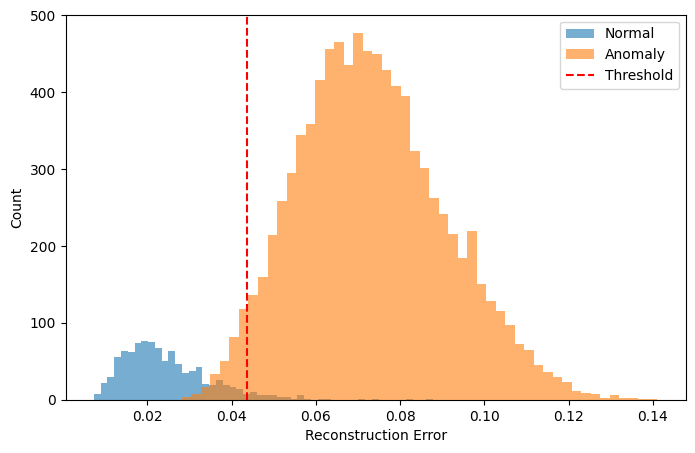

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_errors, bins=50, alpha=0.6, label="Anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.show()


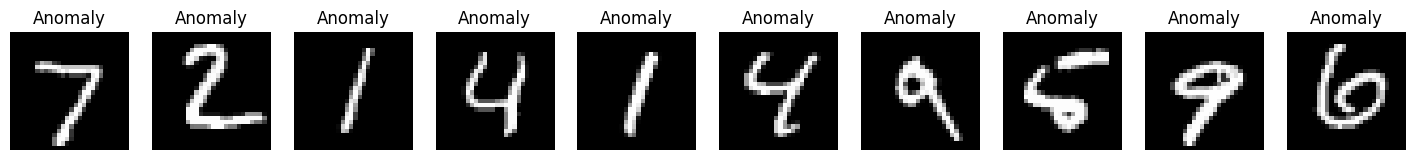

In [12]:
n = 10
anomaly_indices = np.where(anomaly_errors > threshold)[0]

plt.figure(figsize=(18, 4))
for i in range(n):
    idx = anomaly_indices[i]

    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test_anomaly[idx].reshape(28, 28), cmap="gray")
    plt.title("Anomaly")
    plt.axis("off")

plt.show()
